In [1]:
import sounddevice as sd
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import librosa

In [2]:
print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   7 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   8 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
   9 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  10 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  11 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  13 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  14 Analogue 1 + 2 (8- Focusrite USB Audio), Windows WASAPI (2 in, 0 out)
  15 Mic

# <font color="red">**MEASURE THE DISTANCE!!!**</font>


In [5]:
panel_to_err_cm = 4.5
ir_len = 512

## <font color="red">**Did you measure the distance???**</font>


In [6]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [7]:
sharc = Sharc(arthur_96, ad)


MIDI outputs:
  0: Microsoft GS Wavetable Synth 0
  1: Focusrite USB MIDI 1

MIDI inputs:
  0: Focusrite USB MIDI 0


In [16]:
_ = sharc.save_irs()

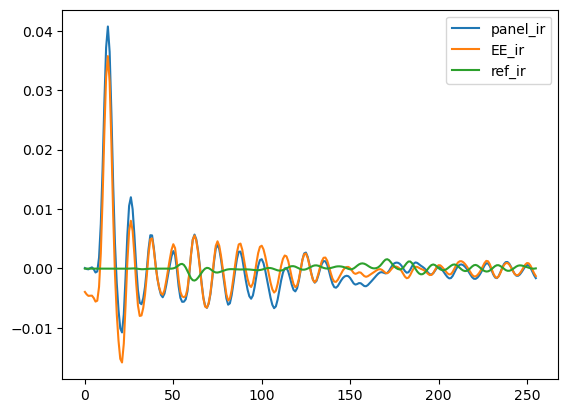

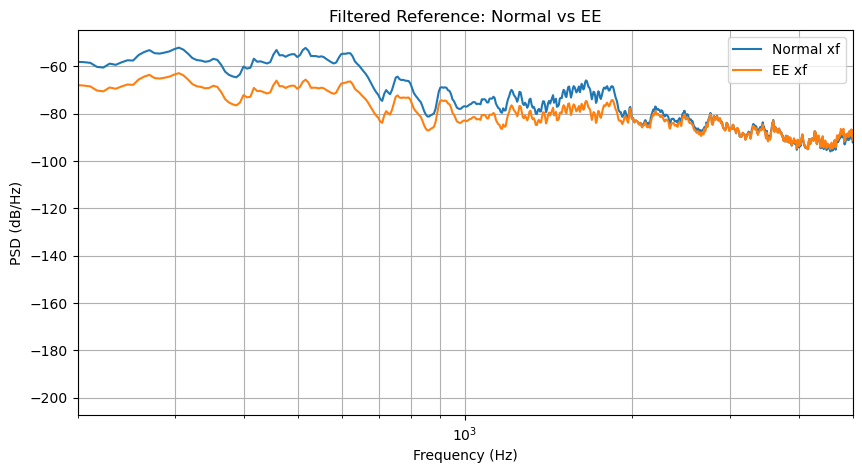

In [8]:
_ = sharc.EE_irs(
    f_low=200,
    f_high=5000,
    alpha=1.0,
    floor_frac=0.05,
    ir_len=ir_len,
    panel_to_err_cm=panel_to_err_cm
)

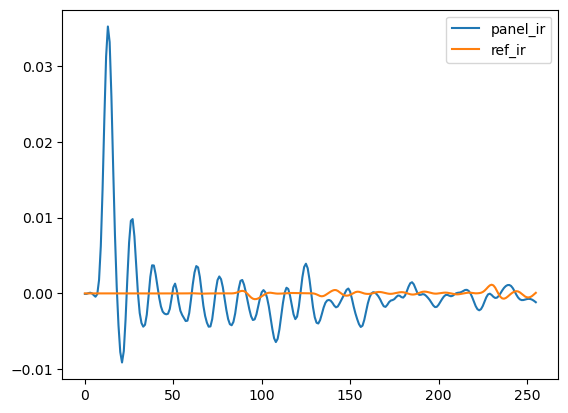

In [17]:
_ = sharc.prep_irs(ir_len=256, panel_to_err_cm=4.5)

In [11]:
error_4_5, ref_4_5 = sharc.save_irs()
dist_4_5 = 4.5


In [12]:
error_11, ref_11 = sharc.save_irs()
dist_11 = 11

In [ ]:
error_27, ref_27 = sharc.save_irs()
dist_27 = 27

In [15]:
import numpy as np
np.savez(
    './data/multiple_irs',
    error_4_5=error_4_5,
    error_11=error_11,
    error_27=error_27,
    ref_4_5=ref_4_5,
    ref_11=ref_11,
    ref_27=ref_27,
    dist_4_5 = dist_4_5,
    dist_11 = dist_11,
    dist_27 = dist_27,
    fs=fs
)

NameError: name 'dist_27' is not defined